<a href="https://colab.research.google.com/github/KModel212/DATA-ANAL-DOMESTIC-VIOLENCE-SUPERAI/blob/main/Domestic_Violence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👪Domestic Violence Incidents in Thailand**

🎯 THackle DataViz Challenge
ประเด็นคำถามสำหรับการวิเคราะห์ข้อมูล


👥 ข้อ 1 — ใครเสี่ยงที่สุด? (Who is at risk?)
📊 จากข้อมูลเกี่ยวกับ ผู้ถูกกระทำความรุนแรง และ ผู้กระทำความรุนแรงในครอบครัว

จงสร้างกราฟหรือ Visualization ที่ช่วยให้ผู้อ่านสามารถมองเห็นได้อย่างชัดเจนว่า
กลุ่มอายุใด
เพศใด
มี ความเสี่ยงสูงที่สุดในแต่ละบทบาท และรูปแบบความเสี่ยงของ ผู้กระทำและผู้ถูกกระทำมีความแตกต่างกันอย่างไร

Visualization ควรช่วยให้ผู้อ่านสามารถ เปรียบเทียบโครงสร้างของทั้งสองกลุ่มได้ในภาพเดียว และสามารถมองเห็น pattern ของความเสี่ยงได้อย่างชัดเจน



📍⏰ ข้อ 2 — เกิดที่ไหน เมื่อไหร่? (Where & When?)
📊 จงสร้าง Visualization ที่แสดง รูปแบบการกระจายตัวของเหตุการณ์ความรุนแรงในครอบครัว

โดยพิจารณาทั้ง
มิติของพื้นที่
มิติของช่วงเวลา
เพื่อให้สามารถมองเห็นว่า เหตุการณ์เหล่านี้เกิดขึ้นที่ใดบ่อยที่สุด และเกิดขึ้นในช่วงเวลาใดมากที่สุด

ผลงานควรช่วยระบุให้เห็นว่า พื้นที่หรือช่วงเวลาใดคือ “จุดวิกฤต (Hotspot)”

ซึ่งอาจต้องได้รับ การจัดสรรทรัพยากร การเฝ้าระวัง หรือมาตรการป้องกันเพิ่มเติมจากหน่วยงานที่เกี่ยวข้อง



⚠️ ข้อ 3 — อะไรคือสัญญาณเตือน? (What triggers violence?)
📊 จากข้อมูลเกี่ยวกับ ปัจจัยเสี่ยงของผู้กระทำความรุนแรงในครอบครัว

จงสร้าง Visualization ที่ช่วยให้ผู้กำหนดนโยบายสามารถเข้าใจได้อย่างรวดเร็วว่า
ปัจจัยใดควรได้รับความสำคัญในการป้องกันก่อน
และ เหตุใดปัจจัยนั้นจึงมีความสำคัญต่อการเกิดเหตุความรุนแรง
ผลงานควรสามารถสื่อสารให้เห็น ลำดับความสำคัญของปัจจัยเสี่ยง และช่วยให้ผู้อ่านเข้าใจว่า
หากต้องออกแบบมาตรการป้องกัน ควรเริ่มต้นจากปัจจัยใดก่อน ผ่านการนำเสนอข้อมูลที่ชัดเจนและเข้าใจง่ายผ่าน Visualization 📊



## 1. set up & understanding data

In [82]:
# import library ที่สำคัญ

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager as fm
from matplotlib import rcParams


!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

plt.rcParams['figure.dpi'] = 120


# โหลดข้อมูล

event_df = pd.read_csv("ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv")
abusers_df = pd.read_csv("ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv")
victims_df = pd.read_csv("ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [83]:
# ทำความเข้าใจข้อมูล
event_df.head()

,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,หนังสือราชการหรือหนังสือจากหน่วยงาน,12:01 – 18:00,สถานที่ส่วนบุคคล
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,18:01 – 00:00,สถานที่ส่วนบุคคล
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,00:01 – 06:00,สถานที่ส่วนบุคคล


In [84]:
event_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877 entries, 0 to 876
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Regional           877 non-null    object
 1   Province           877 non-null    object
 2   District           877 non-null    object
 3   Sub-District       877 non-null    object
 4   Derivation         877 non-null    object
 5   Source             877 non-null    object
 6   Source Type        877 non-null    object
 7   Other Source Type  877 non-null    object
 8   Channel            877 non-null    object
 9   Period             877 non-null    object
 10  Locale             877 non-null    object
dtypes: object(11)
memory usage: 75.5+ KB


In [85]:
abusers_df.head()

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,61,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,26,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,หญิง,55,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,ชาย,33,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่


In [86]:
abusers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Regional              564 non-null    object
 1   Province              564 non-null    object
 2   District              564 non-null    object
 3   Sub-District          564 non-null    object
 4   Gender                564 non-null    object
 5   Age                   564 non-null    int64 
 6   Age Range             564 non-null    object
 7   Relation              564 non-null    object
 8   Mariage Registration  564 non-null    object
 9   Alcohol               564 non-null    object
 10  Drug                  564 non-null    object
 11  Authoritative         564 non-null    object
 12  Rage                  564 non-null    object
 13  Jealous               564 non-null    object
 14  Divorce               564 non-null    object
 15  Health Problem        564 non-null    ob

In [87]:
victims_df.head()

,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
0,ภาคกลาง,กรุงเทพมหานคร,เขตหนองจอก,ลำผักชี,หญิง,18,วัยรุ่น 13 - 18 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ยาย
1,ภาคกลาง,กรุงเทพมหานคร,เขตบางแค,บางแค,หญิง,36,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,พี่น้อง/ลูกพี่ลูกน้อง
2,ภาคกลาง,กรุงเทพมหานคร,เขตทวีวัฒนา,ศาลาธรรมสพน์,ชาย,78,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,บุตร
3,ภาคกลาง,กรุงเทพมหานคร,เขตบางซื่อ,วงศ์สว่าง,หญิง,64,วัยสูงอายุ 60 ปีขึ้นไป,แยกกันอยู่,จดทะเบียนหย่า,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,"คู่ชีวิต,สามี"
4,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ดอกไม้,หญิง,35,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ใช่,ไม่,ไม่,ใช่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"


In [88]:
victims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Regional              597 non-null    object
 1   Province              597 non-null    object
 2   District              597 non-null    object
 3   Sub-District          597 non-null    object
 4   Gender                597 non-null    object
 5   Age                   597 non-null    int64 
 6   Age Range             597 non-null    object
 7   Relation              597 non-null    object
 8   Mariage Registration  597 non-null    object
 9   Alcohol               597 non-null    object
 10  Drug                  597 non-null    object
 11  Authoritative         597 non-null    object
 12  Rage                  597 non-null    object
 13  Jealous               597 non-null    object
 14  Divorce               597 non-null    object
 15  Health Problem        597 non-null    ob

# 2. Data Quality & Cleaning

In [89]:
# ตรวจสอบการกระจายของข้อมูล รวมถึงตรวจหาค่าที่ผิดปกติ ค่าที่ไม่สม่ำเสมอ และรูปแบบของ missing values หรือค่าที่มีความหมายคล้ายกัน
print('event_df')
print('------')
for col in event_df.columns:
    print(col)
    print(event_df[col].value_counts())
    print('------')

event_df
------
Regional
Regional
ภาคกลาง                  382
ภาคตะวันออกเฉียงเหนือ    205
ภาคเหนือ                 164
ภาคใต้                   126
Name: count, dtype: int64
------
Province
Province
กรุงเทพมหานคร      95
ราชบุรี            48
นครราชสีมา         22
น่าน               22
ฉะเชิงเทรา         21
นนทบุรี            20
ขอนแก่น            20
ภูเก็ต             20
อุดรธานี           20
หนองคาย            19
สุราษฎร์ธานี       19
สระบุรี            19
นครศรีธรรมราช      18
พระนครศรีอยุธยา    17
พิษณุโลก           17
เชียงราย           16
กำแพงเพชร          16
นครสวรรค์          14
ร้อยเอ็ด           13
อุทัยธานี          13
ชลบุรี             13
สุพรรณบุรี         13
ระยอง              12
ชัยภูมิ            12
มุกดาหาร           12
สกลนคร             12
มหาสารคาม          11
นครนายก            11
สตูล               11
พิจิตร             11
ชัยนาท             10
ศรีสะเกษ           10
จันทบุรี           10
นครปฐม             10
อ่างทอง            10
กาญจนบุรี           9
ลำพูน  

In [90]:
print('abusers_df')
print('------')
for col in abusers_df.columns:
    print(col)
    print(abusers_df[col].value_counts())
    print('------')

abusers_df
------
Regional
Regional
ภาคกลาง                  257
ภาคตะวันออกเฉียงเหนือ    133
ภาคเหนือ                 115
ภาคใต้                    59
Name: count, dtype: int64
------
Province
Province
กรุงเทพมหานคร      59
ราชบุรี            48
ฉะเชิงเทรา         19
น่าน               19
หนองคาย            16
พิษณุโลก           15
นครราชสีมา         15
ขอนแก่น            13
เชียงราย           12
มุกดาหาร           12
สุพรรณบุรี         11
สตูล               11
ชัยภูมิ            11
ร้อยเอ็ด           11
อุทัยธานี          11
ระยอง              10
กำแพงเพชร          10
สกลนคร             10
อ่างทอง            10
สระบุรี            10
ชัยนาท             10
นนทบุรี            10
พระนครศรีอยุธยา     9
อุดรธานี            9
พิจิตร              9
นครสวรรค์           8
ภูเก็ต              8
ชลบุรี              8
อุตรดิตถ์           8
ชุมพร               7
กาญจนบุรี           7
ลพบุรี              7
จันทบุรี            6
สุรินทร์            6
แพร่                6
สิงห์บุรี           6
บึงกา

In [91]:
print('victims_df')
print('------')
for col in victims_df.columns:
    print(col)
    print(victims_df[col].value_counts())
    print('------')

victims_df
------
Regional
Regional
ภาคกลาง                  277
ภาคตะวันออกเฉียงเหนือ    142
ภาคเหนือ                 116
ภาคใต้                    62
Name: count, dtype: int64
------
Province
Province
กรุงเทพมหานคร      62
ราชบุรี            48
ฉะเชิงเทรา         24
น่าน               19
หนองคาย            16
นครราชสีมา         15
พิษณุโลก           15
ขอนแก่น            15
อ่างทอง            13
มุกดาหาร           13
สุพรรณบุรี         12
อุทัยธานี          11
สตูล               11
กำแพงเพชร          11
ภูเก็ต             11
ร้อยเอ็ด           11
เชียงราย           11
นนทบุรี            11
สระบุรี            10
ระยอง              10
ชัยภูมิ            10
สกลนคร             10
อุดรธานี           10
ชัยนาท             10
สิงห์บุรี           9
พระนครศรีอยุธยา     9
พิจิตร              8
กาญจนบุรี           8
ชลบุรี              8
เพชรบูรณ์           8
นครสวรรค์           8
ลพบุรี              7
ชุมพร               7
สระแก้ว             7
อุตรดิตถ์           7
จันทบุรี            6
มหาสา

In [92]:
# จัดการกับ duplicate rows
event_df = event_df.drop_duplicates()
abusers_df = abusers_df.drop_duplicates()
victims_df = victims_df.drop_duplicates()

In [93]:
# ตรวจสอบ missing value -> ไม่พบ
event_df.isnull().sum()

,0
Regional,0
Province,0
District,0
Sub-District,0
Derivation,0
Source,0
Source Type,0
Other Source Type,0
Channel,0
Period,0


In [94]:
abusers_df.isnull().sum()

,0
Regional,0
Province,0
District,0
Sub-District,0
Gender,0
Age,0
Age Range,0
Relation,0
Mariage Registration,0
Alcohol,0


In [95]:
victims_df.isnull().sum()

,0
Regional,0
Province,0
District,0
Sub-District,0
Gender,0
Age,0
Age Range,0
Relation,0
Mariage Registration,0
Alcohol,0


In [96]:
# คอลัมน์ Relation Type มีเป็น free-text มีความหลากหลายสูง จึงสร้าง column Relation Clean จัดกลุ่มความสัมพันธ์คร่าวๆ

victims_df['Relation Type'] = victims_df['Relation Type'].str.replace('อื่นๆ ', '', regex=False)

In [97]:
def clean_relation(x):
    x = x.strip()

    # Ex-Partner
    if any(w in x for w in ['อดีตสามี','อดีตแฟน','อดีตภรรยา', 'สามีเก่า','แฟนเก่า','ภรรยาเก่า']):
        return 'Ex-Partner'

    # Partner
    if any(w in x for w in ['สามี','ภรรยา','แฟน']):
        return 'Partner'

    # Sibling
    if any(w in x for w in ['พี่','น้อง']):
        return 'Sibling'

    # Parent
    if any(w in x for w in ['บิดา','มารดา','พ่อ','แม่']):
        return 'Parent'

    # Child
    if any(w in x for w in ['บุตร','ลูก']):
        return 'Child'

    # Extended Family
    if any(w in x for w in ['ลุง','ป้า','น้า','ตา','ยาย','ปู่','ย่า','หลาน','เขย','สะใภ้']):
        return 'Extended Family'

    return 'Other'

In [98]:
victims_df['Relation Clean'] = victims_df['Relation Type'].apply(clean_relation)

In [99]:
victims_df['Relation Clean'].value_counts()

,count
Relation Clean,
Partner,214
Parent,128
Child,123
Extended Family,54
Ex-Partner,31
Sibling,28
Other,9


In [100]:
# พบว่าในคอลัม gender ของ victims && abusers df มีประเภท ไม่ระบุเพศ อยู่เพียง 1 row เท่านั้น
# ดังนั้น drop row ไม่ระบุเพศออก เนื่องจาก gender มีผลต่อการวิเคราะห์ข้อมูลและตอบคำถาม
victims_df=victims_df[victims_df['Gender']!='ไม่ระบุเพศ']
abusers_df=abusers_df[abusers_df['Gender']!='ไม่ระบุเพศ']

In [101]:
victims_df['Gender'].value_counts()

,count
Gender,
หญิง,471
ชาย,115


In [102]:
abusers_df['Gender'].value_counts()

,count
Gender,
ชาย,451
หญิง,101


In [103]:
# และสังเกตว่าข้อมูล Mariage Registration ในทั้ง abusers_df และ victims_df มีค่าไม่ระบุสูงถึง 216 จาก 564 และ 318 จาก 597 ตามลำดับ คิดเป็น  38.3% และ 53.3%
# จึง drop column ออกเนื่องจากมี missing values สูงมาก และข้อมูลตรงนี้ไม่ได้มีผลต่อการวิเคราะห์มาก
abusers_df = abusers_df.drop(columns=['Mariage Registration'])
victims_df = victims_df.drop(columns=['Mariage Registration'])

In [104]:
# drop column ที่ไม่เกี่ยวกับการวิเคราะห์ออก

cols_to_drop = [
    'Source',
    'Source Type',
    'Other Source Type',
    'Derivation',
    'Channel',
]

event_df = event_df.drop(columns=cols_to_drop)

# 3. Analysis & Answering Questions

# 👥 ข้อ 1 — ใครเสี่ยงที่สุด? (Who is at risk?)

In [105]:
# สำรวจข้อมูลเบื้องต้น

abusers_df['Gender'].value_counts(normalize=True)

,proportion
Gender,
ชาย,0.817029
หญิง,0.182971


In [106]:
abusers_df['Age Range'].value_counts(normalize=True)

,proportion
Age Range,
วัยกลางคน 36 - 59 ปี,0.516304
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,0.358696
วัยสูงอายุ 60 ปีขึ้นไป,0.096014
วัยรุ่น 13 - 18 ปี,0.021739
วัยเด็กตอนกลาง 7 - 12 ปี,0.007246


In [107]:
victims_df['Gender'].value_counts(normalize=True)

,proportion
Gender,
หญิง,0.803754
ชาย,0.196246


In [108]:
victims_df['Age Range'].value_counts(normalize=True)

,proportion
Age Range,
วัยกลางคน 36 - 59 ปี,0.295222
วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,0.252560
วัยสูงอายุ 60 ปีขึ้นไป,0.180887
วัยรุ่น 13 - 18 ปี,0.122867
วัยเด็กตอนกลาง 7 - 12 ปี,0.097270
วัยเด็กเล็กแรกเกิด - 6 ปี,0.051195


In [109]:
# แยกตารางแต่ละบทบาทที่ groupby เพศ และ ช่วงอายุ

abuser_risks= abusers_df.groupby(['Gender','Age Range'],as_index=False).size()
abuser_risks['Percent'] = abuser_risks['size'].transform(lambda x: x / x.sum())
abuser_risks

,Gender,Age Range,size,Percent
0,ชาย,วัยกลางคน 36 - 59 ปี,238,0.431159
1,ชาย,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,165,0.298913
2,ชาย,วัยรุ่น 13 - 18 ปี,10,0.018116
3,ชาย,วัยสูงอายุ 60 ปีขึ้นไป,35,0.063406
4,ชาย,วัยเด็กตอนกลาง 7 - 12 ปี,3,0.005435
5,หญิง,วัยกลางคน 36 - 59 ปี,47,0.085145
6,หญิง,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,33,0.059783
7,หญิง,วัยรุ่น 13 - 18 ปี,2,0.003623
8,หญิง,วัยสูงอายุ 60 ปีขึ้นไป,18,0.032609
9,หญิง,วัยเด็กตอนกลาง 7 - 12 ปี,1,0.001812


In [110]:
victim_risks= victims_df.groupby(['Gender','Age Range'],as_index=False).size()
victim_risks['Percent'] = victim_risks['size'].transform(lambda x: x / x.sum())
victim_risks

,Gender,Age Range,size,Percent
0,ชาย,วัยกลางคน 36 - 59 ปี,20,0.034130
1,ชาย,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,13,0.022184
2,ชาย,วัยรุ่น 13 - 18 ปี,13,0.022184
3,ชาย,วัยสูงอายุ 60 ปีขึ้นไป,30,0.051195
4,ชาย,วัยเด็กตอนกลาง 7 - 12 ปี,24,0.040956
5,ชาย,วัยเด็กเล็กแรกเกิด - 6 ปี,15,0.025597
6,หญิง,วัยกลางคน 36 - 59 ปี,153,0.261092
7,หญิง,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,135,0.230375
8,หญิง,วัยรุ่น 13 - 18 ปี,59,0.100683
9,หญิง,วัยสูงอายุ 60 ปีขึ้นไป,76,0.129693


In [111]:
# map แต่ละ category ให้เป็นช่วงของตัวเลข เพื่อให้สามารถ sort ได้

age_map = {
    'วัยเด็กเล็กแรกเกิด - 6 ปี': '0-6',
    'วัยเด็กตอนกลาง 7 - 12 ปี': '7-12',
    'วัยรุ่น 13 - 18 ปี': '13-18',
    'วัยผู้ใหญ่ตอนต้น 19 - 35 ปี': '19-35',
    'วัยกลางคน 36 - 59 ปี': '36-59',
    'วัยสูงอายุ 60 ปีขึ้นไป': '60+'
}

victim_risks['Age Range'] = victim_risks['Age Range'].map(age_map)
abuser_risks['Age Range'] = abuser_risks['Age Range'].map(age_map)

victim_risks = victim_risks.sort_values('Age Range')
abuser_risks = abuser_risks.sort_values('Age Range')

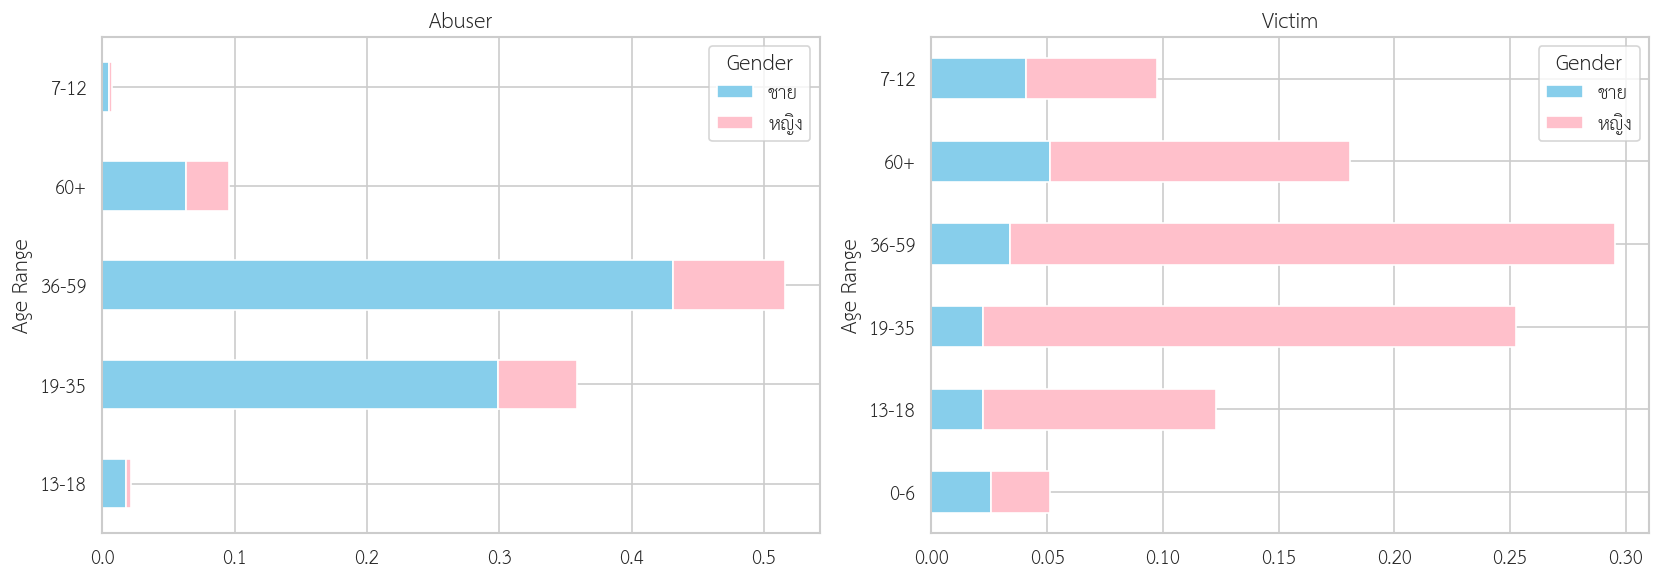

In [112]:
# ใช้ stacked bar chart เพื่อเปรียบเทียบจำนวนผู้กระทำและผู้ถูกกระทำในแต่ละช่วงอายุและเพศ
# เนื่องจากสามารถเห็นทั้ง ยอดรวม และ สัดส่วนภายใน ในกราฟเดียว ทำให้ระบุได้ว่ากลุ่มใดมีความเสี่ยงสูงที่สุดอย่างชัดเจน
abuser_pivot = abuser_risks.pivot(index='Age Range', columns='Gender', values='Percent')
victim_pivot = victim_risks.pivot(index='Age Range', columns='Gender', values='Percent')

gender_colors = {'ชาย': 'skyblue', 'หญิง': 'pink'}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# กราฟผู้กระทำความรุนแรง
abuser_pivot.plot(
    kind='barh',
    stacked=True,
    ax=axes[0],
    title='Abuser',
    color=[gender_colors[col] for col in abuser_pivot.columns]
)

# กราฟผู้ถูกกระทำ
victim_pivot.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    title='Victim',
    color=[gender_colors[col] for col in victim_pivot.columns]
)

plt.tight_layout()
plt.show()

**📊 การวิเคราะห์ (Who is at risk?)**



จากกราฟสามารถระบุได้ชัดเจนว่า กลุ่มเสี่ยงสูงสุดของผู้กระทำและผู้ถูกกระทำมีลักษณะแตกต่างกันอย่างชัดเจน

👤 ผู้กระทำความรุนแรง (Abuser)

* กลุ่มที่มีสัดส่วนสูงที่สุดคือ เพศชาย วัยกลางคน (36–59 ปี)

* รองลงมาคือ เพศชาย วัยผู้ใหญ่ตอนต้น (19–35 ปี)

* เพศหญิงมีสัดส่วนน้อยมากในทุกช่วงอายุ

👉 สรุป:
ผู้กระทำส่วนใหญ่เป็นผู้ชายวัยทำงาน โดยเฉพาะช่วง 36–59 ปี

👥 ผู้ถูกกระทำ (Victim)

* กลุ่มที่มีสัดส่วนสูงที่สุดคือ เพศหญิง วัยกลางคน (36–59 ปี)

* รองลงมาคือ เพศหญิง วัยผู้ใหญ่ตอนต้น (19–35 ปี)

* ในทุกช่วงอายุ “เพศหญิงมีสัดส่วนสูงกว่าเพศชายอย่างชัดเจน”

👉 สรุป:
ผู้ถูกกระทำส่วนใหญ่เป็นผู้หญิงในวัยทำงาน

⚖️ การเปรียบเทียบรูปแบบความเสี่ยง

ทั้งสองบทบาทมี จุดสูงสุดอยู่ในช่วงอายุเดียวกัน (36–59 ปี)

แต่มีความต่างชัดเจนในเรื่องเพศ:

ผู้กระทำ -> ผู้ชายเป็นหลัก

ผู้ถูกกระทำ -> ผู้หญิงเป็นหลัก

👉 แสดงให้เห็น pattern ว่า
ความรุนแรงในครอบครัวส่วนใหญ่เกิดในความสัมพันธ์ระหว่างชาย–หญิงในวัยทำงาน

💡 Insight สำคัญ

วัยทำงาน (19–59 ปี) คือช่วงที่มีความเสี่ยงสูงที่สุดทั้งสองฝั่ง

ความแตกต่างด้านเพศมีความชัดเจนมาก (gender gap สูง)

เด็กและวัยรุ่นมีสัดส่วนน้อยกว่าอย่างเห็นได้ชัด





# 📍⏰ ข้อ 2 — เกิดที่ไหน เมื่อไหร่? (Where & When?)

In [113]:
# เลือกที่จะวิเคราะห์ในระดับจังหวัดเนื่องจากหากวิเคราะห์ลงไปถึง District และ Sub Distirct ข้อมูลจะละเอียดและรกเกินไป
# ตัด column ที่ไม่ใช้
cols = ['Regional', 'Province', 'Period', 'Locale']
df = event_df[cols]

In [114]:
# สำรวจข้อมูลคร่าวๆ
df['Province'].value_counts().head(10)

,count
Province,
กรุงเทพมหานคร,93
ราชบุรี,46
นครราชสีมา,22
น่าน,22
ฉะเชิงเทรา,21
นนทบุรี,20
อุดรธานี,20
ภูเก็ต,20
หนองคาย,19


In [115]:
df['Period'].value_counts()

,count
Period,
12:01 – 18:00,309
06:01 – 12:00,247
18:01 – 00:00,237
00:01 – 06:00,68


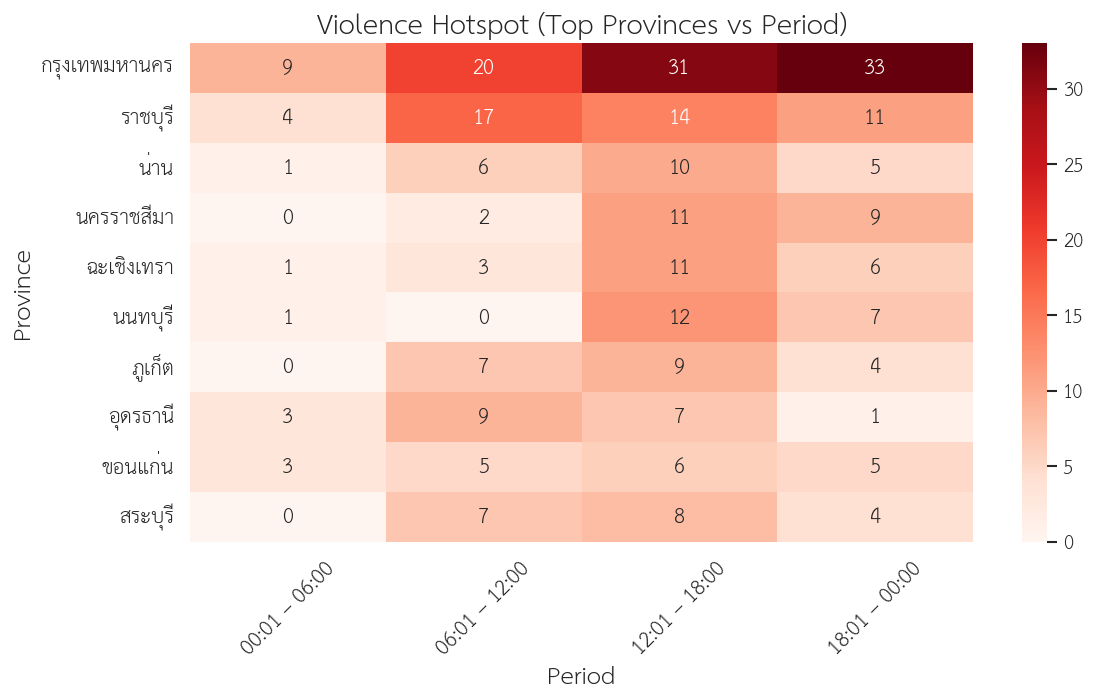

In [116]:
# สร้าง pivot table แสดงจำนวนเหตุการณ์รายจังหวัดต่อช่วงเวลา
# เนื่องจากข้อมูลมีหลายจังหวัดมาก การแสดงทั้งหมดจะดูยาก
# จึงเลือกแสดงเฉพาะ top 10 จังหวัดที่มีเหตุการณ์สูงสุด เพื่อหา hotspot
pivot = event_df.pivot_table(
    index='Province',
    columns='Period',
    aggfunc='size',
    fill_value=0
)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index].head(10)

# เลือกใช้ Heatmap ในการพลอตกราฟแสดงความสัมพันธ์ของ Province และ Period
# เนื่องจากเหมาะสำหรับการแสดงความสัมพันธ์ของข้อมูล 2 มิติ มองเห็น pattern และ hotspot ได้อย่างชัดเจน
# สามารถเปรียบเทียบหฃายจังหวัดและหลายช่าวงเวลาได้พร้อมๆกัน

plt.figure(figsize=(10,6))
sns.heatmap(
    pivot,
    cmap='Reds',
    annot=True,
    fmt='d',
)


plt.title('Violence Hotspot (Top Provinces vs Period)', fontsize=16, fontweight='bold')
plt.xlabel('Period', fontsize=14, fontweight='bold')
plt.ylabel('Province', fontsize=14, fontweight='bold')


plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

จากการวิเคราะห์ Heatmap พบว่า:

*   พื้นที่ที่เกิดเหตุความรุนแรงสูงสุดคือ กรุงเทพมหานคร  โดยมีจำนวนเหตุการณ์สูงกว่าจังหวัดอื่นอย่างชัดเจน
*   ช่วงเวลาที่เกิดเหตุบ่อยที่สุดคือ ช่วงเย็นถึงกลางคืน (18:01–00:00)
* รองลงมาคือช่วง กลางวัน (12:01–18:00)

👉 ดังนั้น Hotspot ของเหตุการณ์คือ
“กรุงเทพมหานคร ในช่วงเวลา 18:01–00:00”


---



📊 Insight เพิ่ม
*  หลายจังหวัดมี pattern คล้ายกัน คือ เหตุเพิ่มขึ้น โดยช่วง กลา
คืน > เย็น > กลางวัน
*  บางจังหวัด (เช่น อุดรธานี) มีแนวโน้มลดลงตอนกลางคืน
* แสดงว่า ช่วงเวลามีผลมากกว่าพื้นที่บางส่วน

# ⚠️ ข้อ 3 — อะไรคือสัญญาณเตือน? (What triggers violence?)

In [117]:
# สร้างตางรางที่ map การเกิดปัจจัยเสี่ยงต่างๆโดย 'ไม่' = 0 'ใช่' = 1 เพื่อง่ายต่อการวิเคราะห์
risk_factors = ['Alcohol', 'Drug', 'Rage', 'Jealous', 'Mental Problem', 'Economics Stress']
risk = abusers_df[risk_factors].apply(lambda col: col.map(lambda x: 1 if x == 'ใช่' else 0))

In [118]:
# ตรวจสอบลำดับความสำคัญของปัจจัยเสี่ยงต่างๆ
risk_summary = risk.sum().sort_values(ascending=False)
risk_summary

,0
Drug,202
Alcohol,174
Rage,165
Jealous,112
Mental Problem,89
Economics Stress,73


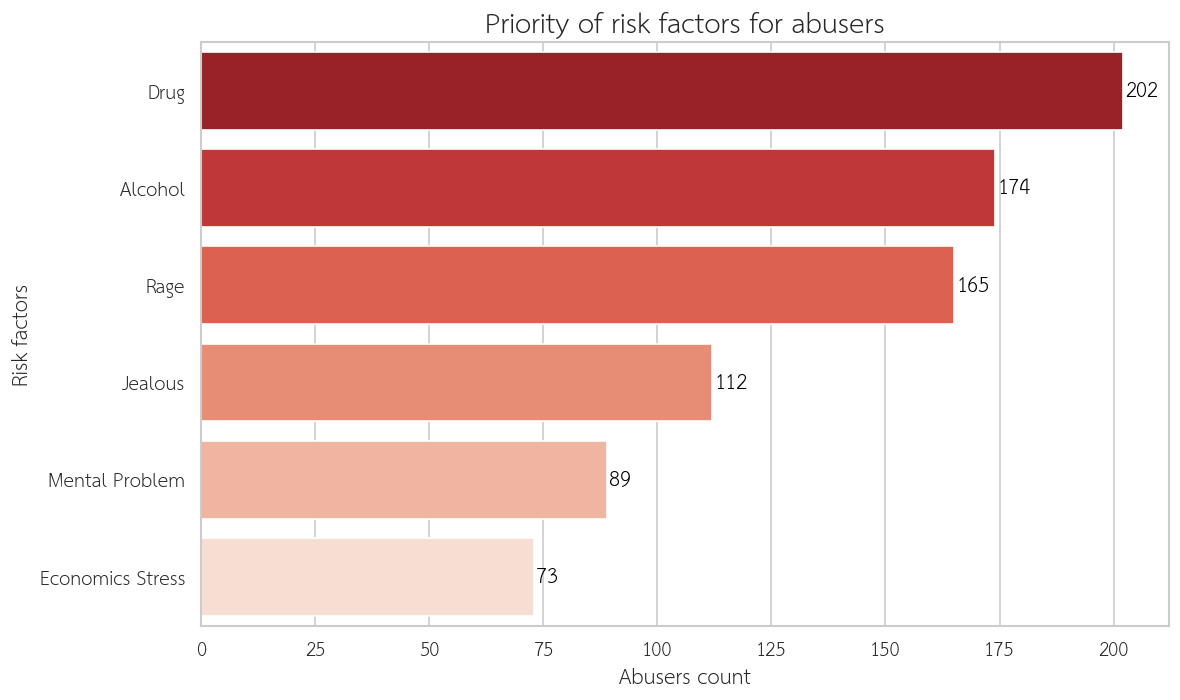

In [119]:
# เลือกใช้ Bar Chart ในการ plot เพราะเป็นตัวเลือกที่เหมาะสมที่สุด เพราะช่วยแสดง “ลำดับความสำคัญของปัจจัยเสี่ยง” ได้อย่างชัดเจน เข้าใจง่าย
# เหมาะสำหรับการเทียบค่าระหว่างหมวกหมู่ต่างๆ สามารถเห็น ranking ได้ชัดเจนจากความยาวของกราฟ

df_plot = risk_summary.reset_index()
df_plot.columns = ['Risk Factor', 'Count']

plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x='Count',
    y='Risk Factor',
    palette="Reds_r",
    hue='Risk Factor',
    dodge=False
)

plt.title("Priority of risk factors for abusers", fontsize=16, fontweight='bold')
plt.xlabel("Abusers count")
plt.ylabel("Risk factors")

for i, v in enumerate(df_plot['Count']):
    plt.text(v + 0.5, i, str(v), color='black', va='center')

plt.tight_layout()
plt.show()

📊 จากการวิเคราะห์ Bar Chart พบว่า:

* ปัจจัยที่มีความสัมพันธ์กับความรุนแรงมากที่สุดคือ Drug โดยมีจำนวนผู้กระทำสูงสุดอย่างชัดเจน
*  รองลงมาคือ Alcohol และ Rage ซึ่งมีจำนวนใกล้เคียงกันและยังอยู่ในระดับสูง
* ปัจจัยอย่าง Jealousy, Mental Problem และ Economic Stress มีผลน้อยกว่าอย่างเห็นได้ชัด

👉 ดังนั้น “ตัวกระตุ้นหลัก (Main triggers)” ของความรุนแรงคือ
“การใช้สารเสพติดและแอลกอฮอล์ รองลงมาคือความโกรธ”



---



📊 Insight เพิ่ม
* ปัจจัยกลุ่ม Substance (Drug + Alcohol) มี impact สูงกว่าปัจจัยอื่นอย่างชัดเจน แสดงว่า “สารเสพติด” เป็น driver หลักของพฤติกรรมรุนแรง
*  ปัจจัยด้านอารมณ์ (Rage, Jealousy) ทำหน้าที่เป็น “ตัวกระตุ้นเสริม” ที่ทำให้ความรุนแรงเกิดง่ายขึ้น
* ปัจจัยเชิงโครงสร้าง (Mental, Economic) มีผล แต่ไม่ใช่ตัวกระตุ้นหลักเมื่อเทียบกับสารเสพติด






# 📌 Conclusion & Policy Implications

จากการวิเคราะห์ข้อมูล (EDA) พบว่า ความรุนแรงในครอบครัวมีความสัมพันธ์อย่างชัดเจนกับปัจจัยด้านพฤติกรรม โดยเฉพาะการใช้สารเสพติด (Drug) และแอลกอฮอล์ (Alcohol) ซึ่งเป็นปัจจัยที่พบมากที่สุดในกลุ่มผู้กระทำความรุนแรง

เมื่อพิจารณาร่วมกับข้อมูลเชิงเวลา พบว่าเหตุการณ์มักเกิดขึ้นในช่วงเย็นถึงกลางคืน ซึ่งเป็นช่วงเวลาที่มีแนวโน้มการใช้สารเสพติดและแอลกอฮอล์สูง สะท้อนให้เห็นถึงความเชื่อมโยงระหว่าง พฤติกรรมเสี่ยง และ ช่วงเวลาเกิดเหตุ อย่างมีนัยสำคัญ

นอกจากนี้ การวิเคราะห์ตามกลุ่มอายุและเพศยังแสดงให้เห็นว่าความรุนแรงกระจุกตัวอยู่ในบางกลุ่มประชากร ซึ่งยิ่งตอกย้ำว่าปัญหานี้เกิดจากหลายปัจจัยร่วมกัน ไม่ใช่เพียงปัจจัยเดียว



---



🎯 Policy Recommendations

จากผลการวิเคราะห์ สามารถเสนอแนวทางเชิงนโยบายได้ดังนี้:
    
  

*   ควรให้ความสำคัญกับการควบคุมการเข้าถึงสารเสพติดและแอลกอฮอล์เป็นลำดับแรก เนื่องจากเป็นปัจจัยหลักที่ส่งผลต่อความรุนแรง
*   เพ่มมาตรการควบคุมหรือเฝ้าระวังในช่วงเวลาเสี่ยงสูง (ช่วงเย็นถึงกลางคืน)
* พัฒนาโปรแกรมจัดการอารมณ์สำหรับกลุ่มเสี่ยง
  



---



💬 Final Insight

ความรุนแรงในครอบครัวไม่ได้เกิดจากปัจจัยเดียว แต่เป็นผลจากการผสมผสานของพฤติกรรมเสี่ยง ช่วงเวลา และลักษณะของกลุ่มประชากร
ดังนั้น การป้องกันที่มีประสิทธิภาพควรมุ่งเน้นทั้งการลดพฤติกรรมเสี่ยงและการจัดการในช่วงเวลาและกลุ่มที่มีความเสี่ยงสูง